# Visualización de la Evaluación de Métodos de Extracción - Resultados Globales
Este notebook consolida los resultados de todos los métodos evaluados en `global_evaluations/` y permite comparar visualmente su rendimiento sin distinguir entre imágenes y texto seleccionable.

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurar estilo de Seaborn
sns.set_theme(style="whitegrid")

# Configurar fuente Palatino
plt.rcParams['font.family'] = 'serif'

### 1. Carga de Datos
Iteramos sobre todos los archivos CSV en la carpeta `global_evaluations/` para crear un único DataFrame consolidado.

In [7]:
eval_dir = Path("global_evaluations")
all_data = []

# Mapeo para convertir el nombre de los archivos al nombre que usamos en la gráfica
name_mapping = {
    'docling': 'Docling',
    'docling_header': 'Docling + header',
    'mineru': 'MinerU',
    'mineru_header': 'MinerU + header',
    'pymupdf': 'PyMuPDF4LLM',
    'pymupdf_header': 'PyMuPDF4LLM + header',
    'pymupdf_text': 'PyMuPDF',
    'pymupdf_text_header': 'PyMuPDF + header',
    'pipeline_final': 'Pipeline Final'
}

# Cargar todos los archivos CSV
if eval_dir.exists():
    for csv_file in eval_dir.glob("*.csv"):
        if csv_file.stem in name_mapping:
            df = pd.read_csv(csv_file)
            df['Metodo'] = name_mapping[csv_file.stem]
            all_data.append(df)

if all_data:
    df_full = pd.concat(all_data, ignore_index=True)
    
    # Limpiar errores: Convertir "Error" a NaN y asegurar que la columna es numérica
    df_full['Puntuación'] = pd.to_numeric(df_full['Puntuación'], errors='coerce')
    df_full = df_full.dropna(subset=['Puntuación'])
    print(f"Cargados {len(df_full)} registros de evaluación en total.")
    
    # Limpiar nombre de archivo: quitar extensión para mostrar solo el stem
    df_full['Archivo'] = df_full['Archivo'].str.replace(r'\.(pdf|image|json)$', '', regex=True)
    
    mean_scores = df_full.groupby('Metodo')['Puntuación'].mean().reset_index()
    
    method_colors = {
        'Docling': '#4A90D9',
        'Docling + header': '#2C5F8E',
        'MinerU': '#63F89C',
        'MinerU + header': '#09C852',
        'PyMuPDF4LLM': '#F8D563',
        'PyMuPDF4LLM + header': '#F4BD0B',
        'PyMuPDF': '#FF745C',
        'PyMuPDF + header': '#D11F00',
        'Pipeline Final': '#9B59B6'
    }
else:
    print("No se encontraron resultados.")
    df_full = pd.DataFrame()
    mean_scores = pd.DataFrame()

Cargados 896 registros de evaluación en total.


### 2. Puntuación Media por Método (Global)
Comparativa global de todos los métodos sin distinguir entre imágenes y texto seleccionable.

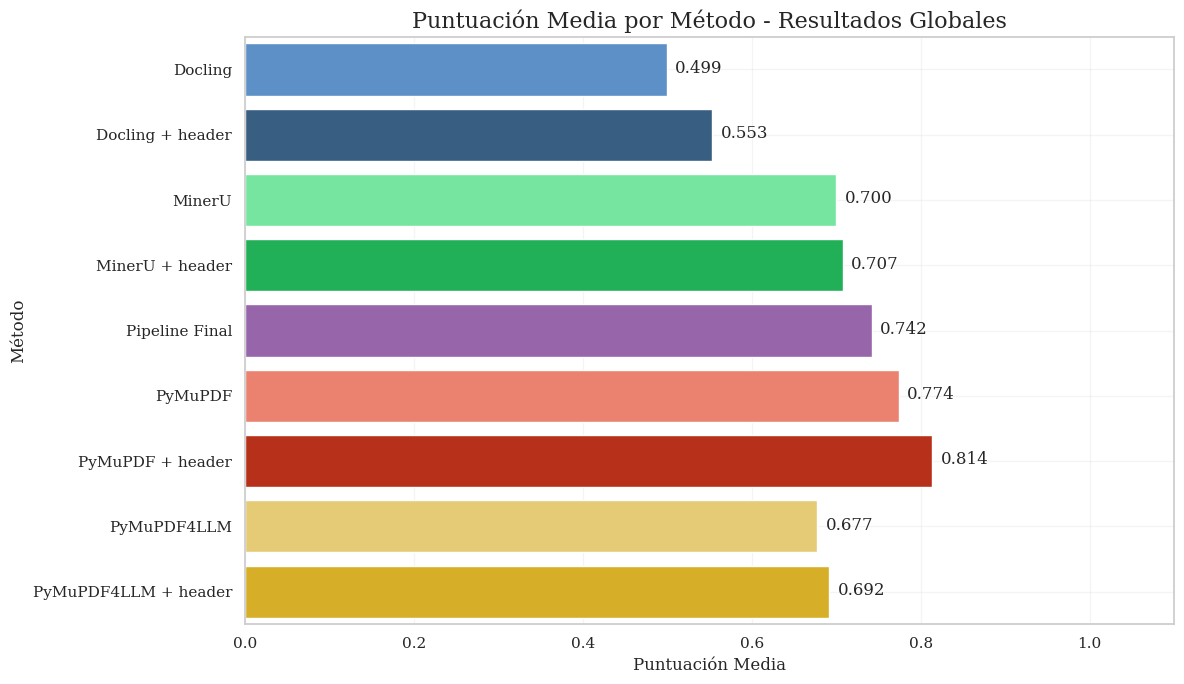

In [ ]:
if not mean_scores.empty:
    plt.figure(figsize=(12, 7))
    
    colors = [method_colors[m] for m in mean_scores['Metodo'].unique()]
    
    ax = sns.barplot(data=mean_scores, x='Puntuación', y='Metodo', hue='Metodo', palette=colors, dodge=False, legend=False)
    plt.title('Puntuación Media por Método - Resultados Globales', fontsize=16)
    plt.xlabel('Puntuación Media', fontsize=12)
    plt.ylabel('Método', fontsize=12)
    
    ax.grid(axis='both', alpha=0.2)
    
    for p in ax.patches:
        width = p.get_width()
        plt.text(width + 0.01, p.get_y() + p.get_height()/2. + 0.05, '{:1.3f}'.format(width), ha="left")
    
    plt.xlim(0, 1.1)
    plt.tight_layout()
    plt.savefig('graficas/barras_global.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No hay datos para visualizar.")

### 3. Distribución de Puntuaciones (Boxplot - Global)
Muestra la dispersión de las puntuaciones para cada método. Si las cajas son pequeñas significa que el modelo es muy consistente. Si hay muchos puntos fuera (outliers) o las cajas son largas, significa que la variabilidad es alta.

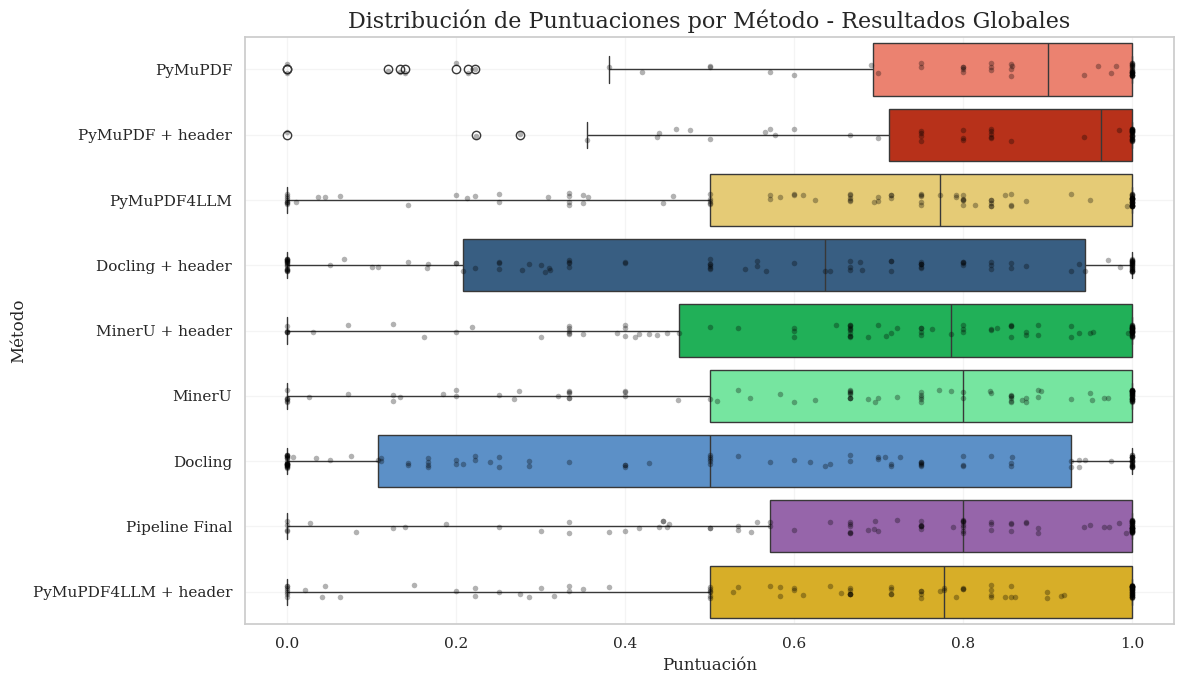

In [9]:
if not df_full.empty:
    plt.figure(figsize=(12, 7))
    
    colors = [method_colors[m] for m in df_full['Metodo'].unique()]
    
    sns.boxplot(data=df_full, x='Puntuación', y='Metodo', hue='Metodo', palette=colors, dodge=False, legend=False)
    sns.stripplot(data=df_full, x='Puntuación', y='Metodo', color='black', alpha=0.3, size=4, jitter=True)
    
    plt.grid(axis='both', alpha=0.2)
    
    plt.title('Distribución de Puntuaciones por Método - Resultados Globales', fontsize=16)
    plt.xlabel('Puntuación', fontsize=12)
    plt.ylabel('Método', fontsize=12)
    
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos para visualizar.")

### 4. Estadísticas Descriptivas
Tabla con estadísticas detalladas por método.

In [10]:
if not df_full.empty:
    stats = df_full.groupby('Metodo')['Puntuación'].describe()
    display(stats)
else:
    print("No hay datos para mostrar estadísticas.")

,count,mean,std,min,25%,50%,75%,max
Metodo,,,,,,,,
Docling,113.0,0.499352,0.392110,0.0,0.107143,0.500000,0.928571,1.0
Docling + header,113.0,0.552735,0.374866,0.0,0.208333,0.636364,0.944375,1.0
MinerU,109.0,0.700177,0.323754,0.0,0.500000,0.800000,1.000000,1.0
MinerU + header,109.0,0.707443,0.304603,0.0,0.464286,0.785714,1.000000,1.0
Pipeline Final,111.0,0.741980,0.288928,0.0,0.571429,0.800000,1.000000,1.0
PyMuPDF,58.0,0.773805,0.306866,0.0,0.693571,0.900429,1.000000,1.0
PyMuPDF + header,58.0,0.813800,0.245098,0.0,0.712500,0.963929,1.000000,1.0
PyMuPDF4LLM,113.0,0.677159,0.329719,0.0,0.500000,0.772750,1.000000,1.0
PyMuPDF4LLM + header,112.0,0.691689,0.326326,0.0,0.500000,0.777778,1.000000,1.0
